<a href="https://colab.research.google.com/github/Arnauld83/Grammy_Awards/blob/main/financial_inclusion_micro_entrepreneurs_Arnauld_kabeya_et_Armel_kalala.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Prédiction de l'Inclusion Financière des Micro-Entrepreneurs

**Membres du groupe :**
- Kalala Kayembe Armel
- Kabeya Muleba Arnauld

**Objectif :** prédire si un individu possède un compte bancaire (proxy de l'inclusion financière) à partir de variables socio-économiques, en comparant deux modèles — **Régression Logistique** (régularisée) et **Random Forest** — avec optimisation des hyperparamètres par validation croisée.

**Données :** *Financial Inclusion in Africa* (enquêtes Finscope 2016-2018 — Kenya, Rwanda, Tanzanie, Ouganda), ≈ 23 500 individus.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
print("Bibliothèques importées ✅")


Bibliothèques importées ✅


## 1. Chargement et prétraitement des données

In [ ]:
url = "https://raw.githubusercontent.com/abdullahi-abubakar/Financial-Inclusion-in-Africa/master/Train_v2.csv"
df = pd.read_csv(url)

colonnes = {
    "country": "pays", "uniqueid": "identifiant_unique", "bank_account": "compte_bancaire",
    "location_type": "type_localisation", "cellphone_access": "acces_telephone",
    "household_size": "taille_menage", "age_of_respondent": "age_repondant",
    "gender_of_respondent": "genre_repondant", "relationship_with_head": "lien_avec_chef_menage",
    "marital_status": "statut_matrimonial", "education_level": "niveau_education",
    "job_type": "type_emploi", "year": "annee",
}
df = df.rename(columns=colonnes)

print(f"Dimensions initiales : {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()


Dimensions initiales : 23524 lignes x 13 colonnes


,pays,annee,identifiant_unique,compte_bancaire,type_localisation,acces_telephone,taille_menage,age_repondant,genre_repondant,lien_avec_chef_menage,statut_matrimonial,niveau_education,type_emploi
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [ ]:
# Nettoyage : doublons, identifiant non prédictif, valeurs manquantes
df = df.drop_duplicates()
df = df.drop(columns=["identifiant_unique"]).dropna()

print(f"Après nettoyage : {df.shape[0]} lignes | valeurs manquantes restantes : {df.isnull().sum().sum()}")


Après nettoyage : 23524 lignes | valeurs manquantes restantes : 0


## 2. Analyse exploratoire rapide (EDA)

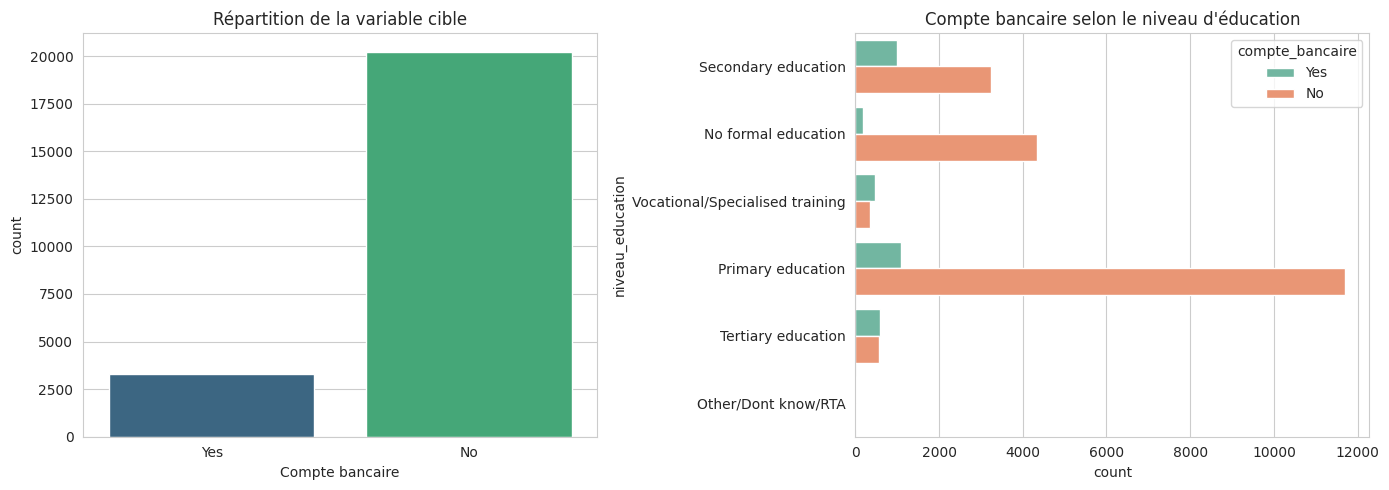

compte_bancaire
No     85.9
Yes    14.1
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="compte_bancaire", palette="viridis", ax=axes[0])
axes[0].set_title("Répartition de la variable cible")
axes[0].set_xlabel("Compte bancaire")

sns.countplot(data=df, y="niveau_education", hue="compte_bancaire", palette="Set2", ax=axes[1])
axes[1].set_title("Compte bancaire selon le niveau d'éducation")

plt.tight_layout()
plt.show()

print((df["compte_bancaire"].value_counts(normalize=True) * 100).round(1))


## 3. Encodage des variables catégorielles

In [ ]:
df_enc = df.copy()
df_enc["compte_bancaire"] = df_enc["compte_bancaire"].map({"Yes": 1, "No": 0})

cols_cat = df_enc.select_dtypes(include="object").columns.tolist()
for col in cols_cat:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop(columns=["compte_bancaire"])
y = df_enc["compte_bancaire"]
print("Variables explicatives :", list(X.columns))


Variables explicatives : ['pays', 'annee', 'type_localisation', 'acces_telephone', 'taille_menage', 'age_repondant', 'genre_repondant', 'lien_avec_chef_menage', 'statut_matrimonial', 'niveau_education', 'type_emploi']


## 4. Séparation train/test et normalisation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")


Train : 18819 | Test : 4705


## 5. Modélisation et optimisation des hyperparamètres

Deux modèles sont comparés :
- **Régression Logistique** — modèle linéaire régularisé (paramètre `C`)
- **Random Forest** — modèle d'ensemble (profondeur, nombre d'arbres, taille des feuilles)

Les hyperparamètres sont optimisés par **GridSearchCV** avec validation croisée stratifiée (5 plis), en maximisant le **F1-score** (classes légèrement déséquilibrées).

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grilles = {
    "Régression Logistique": {
        "modele": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        "params": {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]},
    },
    "Random Forest": {
        "modele": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [200, 400],
            "max_depth": [8, 12, None],
            "min_samples_leaf": [1, 3, 5],
        },
    },
}

meilleurs_modeles = {}
for nom, cfg in grilles.items():
    recherche = GridSearchCV(cfg["modele"], cfg["params"], scoring="f1", cv=cv, n_jobs=-1)
    recherche.fit(X_train_s, y_train)
    meilleurs_modeles[nom] = recherche.best_estimator_
    print(f"✅ {nom} — meilleurs paramètres : {recherche.best_params_} (F1 CV = {recherche.best_score_:.3f})")


✅ Régression Logistique — meilleurs paramètres : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'} (F1 CV = 0.443)
✅ Random Forest — meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200} (F1 CV = 0.522)


## 6. Évaluation et comparaison des modèles

In [ ]:
resultats = []
for nom, modele in meilleurs_modeles.items():
    y_pred = modele.predict(X_test_s)
    y_proba = modele.predict_proba(X_test_s)[:, 1]
    resultats.append({
        "Modèle": nom,
        "Exactitude": accuracy_score(y_test, y_pred),
        "Précision": precision_score(y_test, y_pred),
        "Rappel": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
    })

df_resultats = pd.DataFrame(resultats).sort_values("F1-score", ascending=False).reset_index(drop=True)
df_resultats


,Modèle,Exactitude,Précision,Rappel,F1-score,AUC-ROC
0,Random Forest,0.831243,0.438776,0.714502,0.543678,0.871542
1,Régression Logistique,0.732200,0.315887,0.774924,0.448819,0.836242


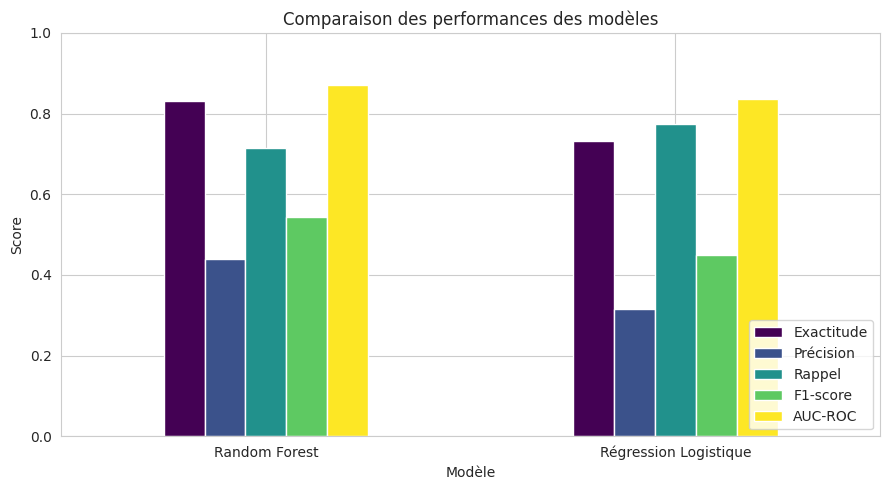

In [ ]:
df_resultats.set_index("Modèle").plot(kind="bar", figsize=(9, 5), colormap="viridis")
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 7. Meilleur modèle : matrice de confusion et variables importantes

🏆 Meilleur modèle : Random Forest

              precision    recall  f1-score   support

         Non       0.95      0.85      0.90      4043
         Oui       0.44      0.71      0.54       662

    accuracy                           0.83      4705
   macro avg       0.69      0.78      0.72      4705
weighted avg       0.88      0.83      0.85      4705



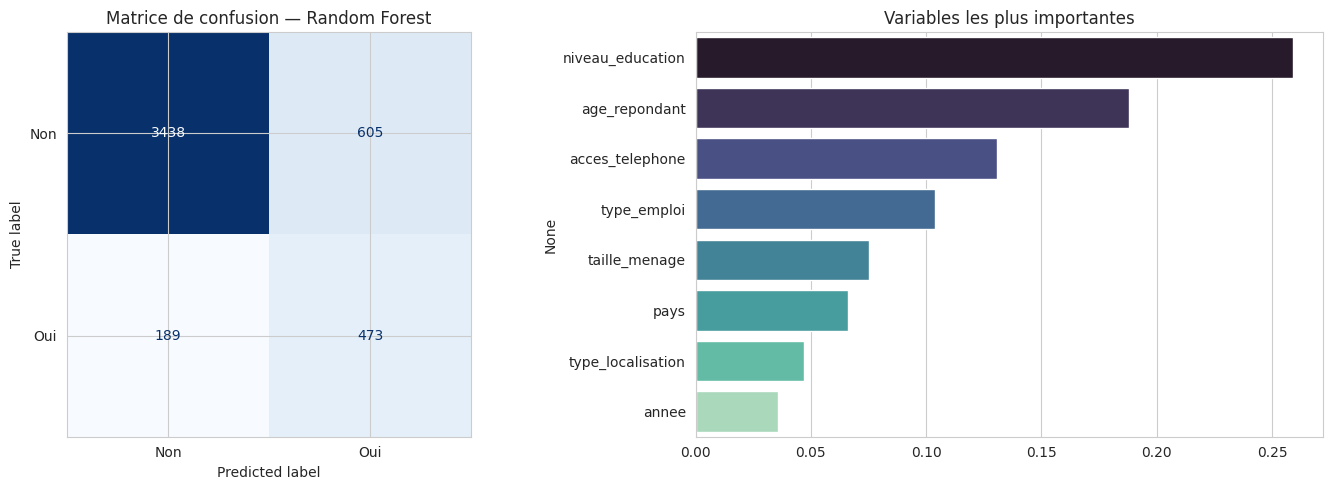

In [ ]:
meilleur_nom = df_resultats.iloc[0]["Modèle"]
meilleur_modele = meilleurs_modeles[meilleur_nom]
y_pred_final = meilleur_modele.predict(X_test_s)

print(f"🏆 Meilleur modèle : {meilleur_nom}\n")
print(classification_report(y_test, y_pred_final, target_names=["Non", "Oui"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Non", "Oui"]).plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title(f"Matrice de confusion — {meilleur_nom}")

if hasattr(meilleur_modele, "feature_importances_"):
    imp = pd.Series(meilleur_modele.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
    sns.barplot(x=imp.values, y=imp.index, palette="mako", ax=axes[1])
    axes[1].set_title("Variables les plus importantes")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()


## 8. Conclusion

- Deux modèles ont été comparés après optimisation de leurs hyperparamètres par validation croisée (GridSearchCV, 5 plis, F1-score) : **Régression Logistique** (régularisée) et **Random Forest**.
- Le modèle en tête du tableau comparatif (section 6) offre le meilleur compromis précision/rappel.
- Les variables les plus influentes dans la possession d'un compte bancaire sont généralement le **niveau d'éducation**, le **type d'emploi**, l'**âge** et l'**accès à un téléphone portable**.
- Ces résultats peuvent orienter les politiques d'inclusion financière vers les populations les moins couvertes (zones rurales, faible éducation, absence de téléphone), notamment les micro-entrepreneurs.